In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# Constants class, values are loaded from UTILS.py
from UTILS import mass, dt, bohr_magneton, kB
from UTILS import Temperature, Temperature_transv
from UTILS import Zmin, Zmax, Zmid, zacceptance_min, zacceptance_max
from UTILS import harmonic_degree, harmonic_coefficient

Temperature        = 5e-3 # K
Temperature_transv = 10e-3 # K
theta              = 20
tau_mixing         = 1
stringa            = ""

class constants:
    def __init__(self, 
                 mass, 
                 dt, 
                 bohr_magneton,
                 kB,
                 Temperature,
                 Temperature_transv,
                 Zmin,
                 Zmax,
                 Zmid,
                 zacceptance_min,
                 zacceptance_max,
                 harmonic_degree,
                 harmonic_coefficient,
                 tau_mixing):
        self.mass = mass
        self.dt = dt
        self.bohr_magneton = bohr_magneton
        self.kB = kB
        self.Temperature = Temperature
        self.Temperature_transv = Temperature_transv
        self.Zmin = Zmin
        self.Zmax = Zmax
        self.Zmid = Zmid
        self.zacceptance_min = zacceptance_min
        self.zacceptance_max = zacceptance_max
        self.harmonic_degree = harmonic_degree
        self.harmonic_coefficient = harmonic_coefficient
        self.tau_mixing = tau_mixing
    mu_eff_over_m = bohr_magneton / mass

CONSTANTS = constants(mass, 
                 dt, 
                 bohr_magneton,
                 kB,
                 Temperature,
                 Temperature_transv,
                 Zmin,
                 Zmax,
                 Zmid,
                 zacceptance_min,
                 zacceptance_max,
                 harmonic_degree,
                 harmonic_coefficient,
                 tau_mixing)

print(CONSTANTS.Temperature, CONSTANTS.Temperature_transv)

0.005 0.01


/home/adriano/.local/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [3]:
# Make Plot Nicer
def plotter_nicer(titlex, titley):
    plt.ylabel(titley, fontsize = 18, loc = "top")
    plt.xlabel(titlex, loc = 'right', fontsize = 18)
    
    plt.grid()
    plt.minorticks_on()
    plt.grid(which='major', linestyle='-', color='black', alpha = 0.5) #Griglia maggiore: linea continua nera
    plt.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia

In [4]:
stringa = "GravityRelease_5mT_well"
# Parameters
bias = 0

In [5]:
data = np.genfromtxt(f"Bfield_nog_csv/{stringa}_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )

print(type(data))

Z  = data['z_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]

mask      = (Z <= CONSTANTS.Zmid) # Take half the potential
Z_half    = Z[mask]     # select half Z array
Uz_half   = Uz[mask]    # select half potential

Z_mirror  = 2*CONSTANTS.Zmid - Z_half[::-1] # Reconstruct Z array after mirroring
Uz_mirror = Uz_half[::-1] # mirror the potential

# concatenate

print(Z)
print(Z_half)
print(Z_mirror)

Z_new     = np.concatenate([Z_half,  Z_mirror[1:]])
Uz_new    = np.concatenate([Uz_half, Uz_mirror[:-1]])

print(Z_new, len(Uz_new))  # uguali

<class 'numpy.ndarray'>
[-2.997 -2.994 -2.991 ...  2.994  2.997  3.   ]
[-2.997  -2.994  -2.991  ... -0.5445 -0.544  -0.5435]
[-0.5433 -0.5428 -0.5423 ...  1.9042  1.9072  1.9102]
[-2.997  -2.994  -2.991  ...  1.9042  1.9072  1.9102] 3159


<ErrorbarContainer object of 3 artists>

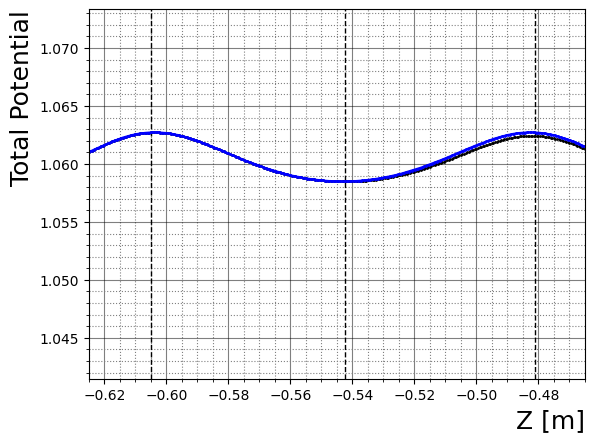

In [6]:
plotter_nicer("Z [m]", "Total Potential")

#plt.xlim(-1.625, +0.465)
#massimo = np.max(data["Total_potential_T__Bz_on_axis"]); plt.ylim(massimo*0.999, massimo*1.001)

plt.axvline(CONSTANTS.Zmin, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(CONSTANTS.Zmid + 0.0011, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(CONSTANTS.Zmax, linestyle = "--", color = "black", linewidth = 1)
massimo = np.max(Uz_new); plt.ylim(massimo*0.98, massimo*1.01)
plt.xlim(-0.625, -0.465)

plt.errorbar(data['z_mm__Bz_on_axis']/1000,
             data["Total_potential_T__Bz_on_axis"], 
             linestyle = '', 
             marker = '.', 
             markersize = 2, 
             color = "black")

plt.errorbar(Z_new,
             Uz_new,
             linestyle = '-', 
             marker = '.', 
             markersize = 2, 
             color = "blue")

# Plot the Bfield maxima

<ErrorbarContainer object of 3 artists>

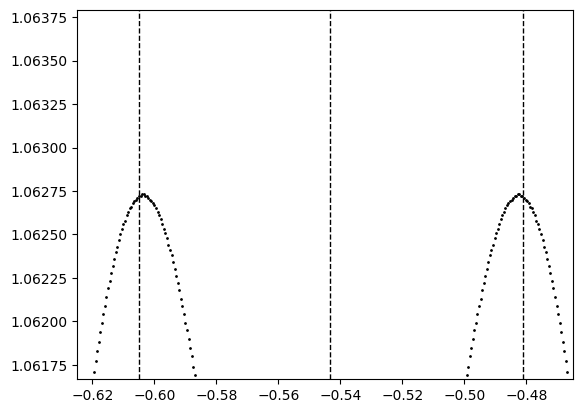

In [7]:
plt.xlim(-0.625, -0.465)
massimo = np.max(Uz_new); plt.ylim(massimo*0.999, massimo*1.001)

plt.axvline(CONSTANTS.Zmin, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(CONSTANTS.Zmid, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(CONSTANTS.Zmax, linestyle = "--", color = "black", linewidth = 1)
plt.errorbar(Z_new,Uz_new, linestyle = '', marker = '.', markersize = 2, color = "black")

# create an artificial bias

given $z_1$ and $z_2$ left and right potential peak position, we have that:
$U_{2}^{'} = U_{0} + (U_{2} - U_{0}) \cdot (1 + p) $. Imposing that $U_{2}^{'} - U_{1} = 2.2G$ leads to:

$ p = \frac{2.2 \cdot 10^{-4} T}{(U_{2} - U_{0})}$

In [8]:
index = np.argmin(np.abs(Z_new - CONSTANTS.Zmid)) # index relative to the potential well center

index_max = np.argmin(np.abs(Z_new - CONSTANTS.Zmin)) # index relative to the potential left peak

#U2 = Uz_new[index_max]
U2 = np.max(Uz_new[:index])
print("U2 left peak, this will be unchanged: %f T" % U2)
U0 = Uz_new[index]
print("U0 minimum, this will be unchanged: %f T" % U0)

p = bias * 2.2*1e-4 / (U2 - U0)

mask   = (Z_new >= CONSTANTS.Zmid)
mask_1 = Uz_new > Uz_new[index]

Uz_new[mask & mask_1] =  Uz_new[index] + (Uz_new[mask & mask_1] - Uz_new[index]) * (1 + p)

print(np.max(Uz_new[:index]), " T " , np.max(Uz_new[index:]), " T")
print(Z_new[np.argmax(Uz_new[:index])], " m ", Z_new[index + np.argmax(Uz_new[index:])], " m")

print(- Z_new[np.argmax(Uz_new[:index])] + CONSTANTS.Zmid, " m ",  Z_new[index + np.argmax(Uz_new[index:])] - CONSTANTS.Zmid, " m")

U2 left peak, this will be unchanged: 1.062730 T
U0 minimum, this will be unchanged: 1.058490 T
1.06273  T  1.06273  T
-0.604  m  -0.4828  m
0.06059999999999999  m  0.06059999999999999  m


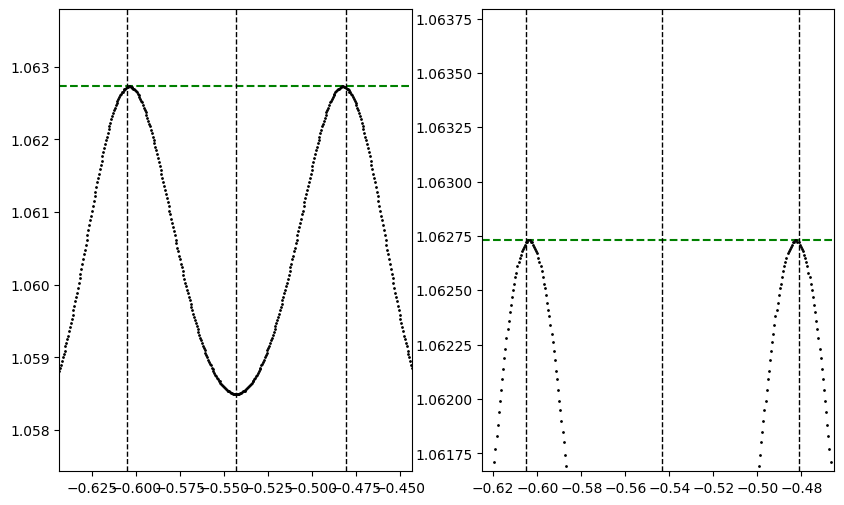

In [12]:
plt.figure(0, figsize = (10, 6))
plt.subplot(1,2,1)
plt.xlim(CONSTANTS.Zmid - 0.100, CONSTANTS.Zmid + 0.100)
massimo = np.max(Uz_new); plt.ylim(U0*0.999, massimo*1.001)

plt.axhline(U2, linestyle = "--", color = "green")
plt.axvline(CONSTANTS.Zmin, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(CONSTANTS.Zmid, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(CONSTANTS.Zmax, linestyle = "--", color = "black", linewidth = 1)
plt.errorbar(Z_new,Uz_new, linestyle = '', marker = '.', markersize = 2, color = "black")

plt.subplot(1,2,2)
plt.xlim(-0.625, -0.465)
massimo = np.max(Uz_new); plt.ylim(massimo*0.999, massimo*1.001)

plt.axhline(U2, linestyle = "--", color = "green")
plt.axvline(CONSTANTS.Zmin, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(CONSTANTS.Zmid, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(CONSTANTS.Zmax, linestyle = "--", color = "black", linewidth = 1)
plt.errorbar(Z_new,Uz_new, linestyle = '', marker = '.', markersize = 2, color = "black")

plt.savefig(f"Bfield_artificial/{stringa }_{(str(bias).replace('.','p') + 'g')}.png")

In [10]:
N = len(Z_new)
data_new = np.empty(N, dtype=data.dtype)

data_new['z_mm__Bz_on_axis'] = Z_new * 1000
data_new['Total_potential_T__Bz_on_axis'] = Uz_new

In [11]:
out_file = f"Bfield_artificial/{stringa }_{(str(bias).replace('.','p') + 'g')}.csv"

header = ",".join(data.dtype.names)

np.savetxt(
    out_file,
    data_new,
    delimiter=",",
    header=header,
    comments=''   # IMPORTANTISSIMO: evita il "#"
)